<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/ba/May2008gasolineCA.jpg/379px-May2008gasolineCA.jpg" width="200px;" alt="gas prices"/>

#   `lesson01`:  Collecting, organizing, and analyzing data

## Objectives

### Objectives

1. Identify the pieces of a Pandas dataframe for a set of data.
2. Interpret data through plotting. 
3. Apply data filtering techniques to prepare the data for analysis.
4. Organize multiple data sets for analysis.
5. Construct a comparison between two sets of data.

### Example Questions

1. What are the column types in your dataframe?
2. How do you plot a column of data?
3. Which data needs to be modified in your dataframe?
4. How do you plot two time series?
5. How would you correlate two series of data?

## Highlevel topics

- Data importing and storage
- Data cleaning
- Data plotting
- Plot manipulation
- Data analysis using built-in tools

## Synopsis

You are a data scientist working for a DC think tank, and your team is studying technology and energy policy.  To prepare for an upcoming energy sumit you are studying the relationship between **US fuel prices** and **fuel efficiency**, measured in miles-per-gallon.

#### Your Task

Your goal is to identify trends in two different datasets on **US fuel prices** and **fuel efficiency**.

## Datasets

In this session two datasets will be used:
- Automotive Trends Report
    - This dataset provides **miles per gallon** on light-duty vehicles
    - https://www.epa.gov/automotive-trends/explore-automotive-trends-data
    - https://www.epa.gov/automotive-trends/about-automotive-trends-data
- Retail motor gasoline and on-highway diesel fuel prices
    - This dataset provides **fuel prices**
    - https://www.eia.gov/totalenergy/data/browser/index.php?tbl=T09.04#/
    - (section 9.4) https://www.eia.gov/totalenergy/data/monthly/index.php

Both of these datasets are already downloaded for you as `table_export.csv` (for MPG data) and `MER_T09_04.csv` (for fuel price data).  However, they could easily be downloaded from the above sites.  For example, the following shell command would download the second dataset:
```
wget https://www.eia.gov/totalenergy/data/browser/csv.php\?tbl\=T09.04 -O MER_T09_04.csv
```

## Getting Started


### Setting up Python

First, import a few Python packages that we'll use throught the course.  By convention these are abbreviated on import.

- `matplotlib` and the interface `matplotlib.pyplot` for plotting
- `numpy` for numerical functions and arrays
- `pandas` for data structures and analysis
- `seaborn` for additional plotting and improved figures

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

%matplotlib inline

### Import data

Here we will import the data with Pandas `read_csv` function and store as a *dataframe*.  

What is a *dataframe*?  It's a storage container (provided by Pandas) that functions like a table.  It can also be viewed as a dictionary.  Pandas dataframes have lots of useful functions, many of which we won't use in this lesson (see [Pandas dataframe documenation](http://pandas.pydata.org/pandas-docs/stable/reference/frame.html) for more details).

In [3]:
ecodf = pd.read_csv('table_export.csv')

### Example dataframe

Let's construct a mock dataframe to highlight some basic functionality.

In [4]:
mydf = pd.DataFrame(
    {'month': ['January', 'February', 'March'],
     'temperature': [20, 30, 40],
     'snowfall': [12.5, 15, 'trace']
    }
)

We can inspect the dataframe in a few different ways:

- `mydf.info()` shows a highlevel view of the dataframe as a data structure
- `mydf` or `print(mydf)` will give a tabular view

In [5]:
mydf

,month,temperature,snowfall
0,January,20,12.5
1,February,30,15
2,March,40,trace


In [6]:
pd.to_datetime('2017', format='%Y')

Timestamp('2017-01-01 00:00:00')

In [7]:
mydf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
month          3 non-null object
temperature    3 non-null int64
snowfall       3 non-null object
dtypes: int64(1), object(2)
memory usage: 152.0+ bytes


In [8]:
mydf

,month,temperature,snowfall
0,January,20,12.5
1,February,30,15
2,March,40,trace


We can access a given column of a dataframe using the bracket notation with the column label.

In [9]:
mydf['temperature']

0    20
1    30
2    40
Name: temperature, dtype: int64

Also notice that each column is a Pandas *series*.  A series is simply array of values with an index to those values.

In [10]:
type(mydf['temperature'])

pandas.core.series.Series

#### Pandas methods

In the following we'll be doing mainly three things to data stored like `mydf`:

1. formatting the data
2. setting an index
3. cleaning the data

We'll work with the example dataframe for now.  Later, we'll work with the datasets described above and we'll also merge data and introduce some analytics.

In [11]:
mydf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
month          3 non-null object
temperature    3 non-null int64
snowfall       3 non-null object
dtypes: int64(1), object(2)
memory usage: 152.0+ bytes


#### (1)
Let's *format* the data so that the `month` is an actual datetime format.  We can do this using [`pd.to_datetime()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html).
For this we need to refer to the string format of dates in Python's `time` format:
https://docs.python.org/3/library/time.html#time.strftime

Notice that `%B` means the month name.

In [12]:
pd.to_datetime('2019 January', format='%Y %B')

Timestamp('2019-01-01 00:00:00')

In [13]:
pd.to_datetime(mydf['month'], format='%B')

0   1900-01-01
1   1900-02-01
2   1900-03-01
Name: month, dtype: datetime64[ns]

Notice, the above command doesn't  actually change the column of our dataframe `mydf`.

In [14]:
mydf['month']

0     January
1    February
2       March
Name: month, dtype: object

To add a year, we would use `%Y`.  To change our dataframe, we set the column equal to the new series.

In [15]:
mydf['month'] = pd.to_datetime(mydf['month']+'2019', format='%B%Y')

In [16]:
mydf

,month,temperature,snowfall
0,2019-01-01,20,12.5
1,2019-02-01,30,15
2,2019-03-01,40,trace


In [17]:
mydf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
month          3 non-null datetime64[ns]
temperature    3 non-null int64
snowfall       3 non-null object
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 152.0+ bytes


#### (2)

Each column of a Pandas dataframe is a series and the default is to index this series with integer indices starting at 0.  We can see what the current index values are by accessing the dataframe's `index` attribute (not a function).  We can also set the index to another set of labels, say the months using the dataframe's `set_index()` function.

In [18]:
mydf.index

RangeIndex(start=0, stop=3, step=1)

In [19]:
mydf.set_index('month', inplace=True)

Notice we used `inplace=True` above so it modified `mydf` instead of making a new object.  We can look at the modified index and dataframe:

In [20]:
mydf.index

DatetimeIndex(['2019-01-01', '2019-02-01', '2019-03-01'], dtype='datetime64[ns]', name='month', freq=None)

In [21]:
mydf

,temperature,snowfall
month,,
2019-01-01,20,12.5
2019-02-01,30,15
2019-03-01,40,trace


#### (3)

Notice that the last value of snowfall is "trace" (a small amount of snow, but no measurable accumulation).  Unfortunately, this isn't very helpful -- we cannot take the average (or many of the other summary statistics) of a string.

In [22]:
mydf['snowfall'].mean()

TypeError: unsupported operand type(s) for +: 'float' and 'str'

Since "trace" means a small amount, it's fairly reasonable to represent it as 0.  So we're going to construct a function that we can `apply()` to each entry.  Let's check to see if the entry is "trace" and if so, set it to 0.0.

In [23]:
def f(x):
    if x == 'trace':
        return 0.0
    else:
        return x

mydf['snowfall'] = mydf['snowfall'].apply(f)
mydf

,temperature,snowfall
month,,
2019-01-01,20,12.5
2019-02-01,30,15.0
2019-03-01,40,0.0


Now that "trace" is removed, we can take the average.

In [24]:
mydf['snowfall'].mean()

9.166666666666666

## The fuel economy dataset

Using the practice from the `mydf` example, let's take a look at the `ecodf` dataframe we obtained above from importing the fuel economy dataset.

In [25]:
ecodf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 13 columns):
Model Year                  344 non-null object
Regulatory Class            344 non-null object
Vehicle Type                344 non-null object
Production Share (%)        344 non-null float64
Adjusted MPG                344 non-null float64
Adjusted MPG_City           344 non-null float64
Adjusted MPG_Hwy            344 non-null float64
Adjusted CO2 (g/mi)         344 non-null int64
Adjusted CO2_City (g/mi)    344 non-null int64
Adjusted CO2_Hwy (g/mi)     344 non-null int64
Weight (lbs)                344 non-null int64
Horsepower (hp)             344 non-null float64
Footprint (sq. ft.)         344 non-null object
dtypes: float64(5), int64(4), object(4)
memory usage: 35.0+ KB


In [26]:
ecodf

,Model Year,Regulatory Class,Vehicle Type,Production Share (%),Adjusted MPG,Adjusted MPG_City,Adjusted MPG_Hwy,Adjusted CO2 (g/mi),Adjusted CO2_City (g/mi),Adjusted CO2_Hwy (g/mi),Weight (lbs),Horsepower (hp),Footprint (sq. ft.)
0,1975,All,All,100.0,13.1,12.00,14.6,681,740,608,4060,137.0,-
1,1975,Car,All Car,80.7,13.5,12.30,15.2,661,722,586,4057,136.0,-
2,1975,Car,Car SUV,0.1,11.1,10.10,12.6,799,877,703,4000,113.0,-
3,1975,Car,Sedan/Wagon,80.6,13.5,12.30,15.2,660,722,586,4058,136.0,-
4,1975,Truck,All Truck,19.3,11.6,10.90,12.7,764,814,702,4073,142.0,-
5,1975,Truck,Pickup,13.1,11.9,11.10,13.1,746,802,677,4012,141.0,-
6,1975,Truck,Truck SUV,1.7,11.0,10.60,11.5,806,837,769,4214,148.0,-
7,1975,Truck,Van,4.5,11.1,10.60,11.9,800,842,749,4196,143.0,-
8,1976,All,All,100.0,14.2,13.20,15.7,625,674,565,4079,135.0,-
9,1976,Car,All Car,78.9,14.9,13.70,16.6,598,649,536,4059,134.0,-


Take a look at the columns --- we'll be considering the 'Adjusted MPG' for our analysis.

In [27]:
ecodf.columns

Index(['Model Year', 'Regulatory Class', 'Vehicle Type',
       'Production Share (%)', 'Adjusted MPG', 'Adjusted MPG_City',
       'Adjusted MPG_Hwy', 'Adjusted CO2 (g/mi)', 'Adjusted CO2_City (g/mi)',
       'Adjusted CO2_Hwy (g/mi)', 'Weight (lbs)', 'Horsepower (hp)',
       'Footprint (sq. ft.)'],
      dtype='object')

### Plot the MPG

Let's try to plot the values of `Adjusted MPG` using the `plot()` method for series.

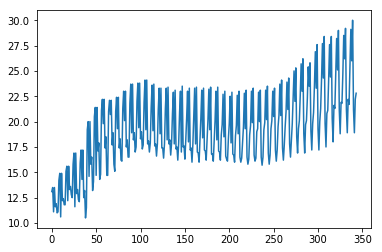

In [28]:
ecodf['Adjusted MPG'].plot()

#### How can we improve this?

1. It looks like we're indexing this by integers (the x-axis).  A more helpful view would be years (or dates).
2. From the dataset above, all vehicle types are being plotted (so there are multiple values corresponding to each year).  Try plotting only for the vehicle type `Car SUV`, for example.
3. The plot needs **labels** (axes, legend) and improved formatting (look, size, font).

#### (1) formatting the dates

Let's format the `Model Year` column and set it as our index.

In [29]:
pd.to_datetime(ecodf['Model Year'], format='%Y')

ValueError: time data 'Prelim. 2017' does not match format '%Y' (match)

Since the most recent data is marked as preliminary, it's a string that isn't being recognized as a year.
We'll have to work around that manually.

In [30]:
'Prelim. 2017'.split()[-1]

'2017'

In [31]:
def f(t):
    if 'Prelim.' in t:
        t = t.split(' ')[-1]
    timestamp = pd.datetime.strptime(t, '%Y')
    return timestamp

ecodf['Model Year'] = ecodf['Model Year'].apply(f)

In [32]:
ecodf.set_index('Model Year', inplace=True)
ecodf

,Regulatory Class,Vehicle Type,Production Share (%),Adjusted MPG,Adjusted MPG_City,Adjusted MPG_Hwy,Adjusted CO2 (g/mi),Adjusted CO2_City (g/mi),Adjusted CO2_Hwy (g/mi),Weight (lbs),Horsepower (hp),Footprint (sq. ft.)
Model Year,,,,,,,,,,,,
1975-01-01,All,All,100.0,13.1,12.00,14.6,681,740,608,4060,137.0,-
1975-01-01,Car,All Car,80.7,13.5,12.30,15.2,661,722,586,4057,136.0,-
1975-01-01,Car,Car SUV,0.1,11.1,10.10,12.6,799,877,703,4000,113.0,-
1975-01-01,Car,Sedan/Wagon,80.6,13.5,12.30,15.2,660,722,586,4058,136.0,-
1975-01-01,Truck,All Truck,19.3,11.6,10.90,12.7,764,814,702,4073,142.0,-
1975-01-01,Truck,Pickup,13.1,11.9,11.10,13.1,746,802,677,4012,141.0,-
1975-01-01,Truck,Truck SUV,1.7,11.0,10.60,11.5,806,837,769,4214,148.0,-
1975-01-01,Truck,Van,4.5,11.1,10.60,11.9,800,842,749,4196,143.0,-
1976-01-01,All,All,100.0,14.2,13.20,15.7,625,674,565,4079,135.0,-


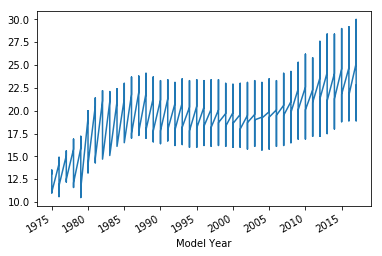

In [33]:
ecodf['Adjusted MPG'].plot()

#### (2)

We still have multiple vehicle types being plotted for each year (the large oscillating pattern).
Now check to see where the `Vehicle Type` is equal to `Car SUV` and only plot that data.

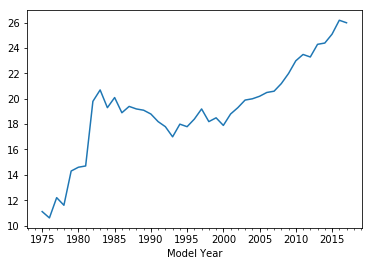

In [34]:
ecodf[
ecodf['Vehicle Type']=='Car SUV'
]['Adjusted MPG'].plot()

#### (3)

Note that changing the index automatically applied the index column label as the x-axis label.

But, there's still a lot we can do to improve the plot with more labels and other
visual formatting changes.

First, we'll adjust the image size, add axis labels/legend, and make the line thicker.


Text(0, 0.5, 'Miles Per Gallon')

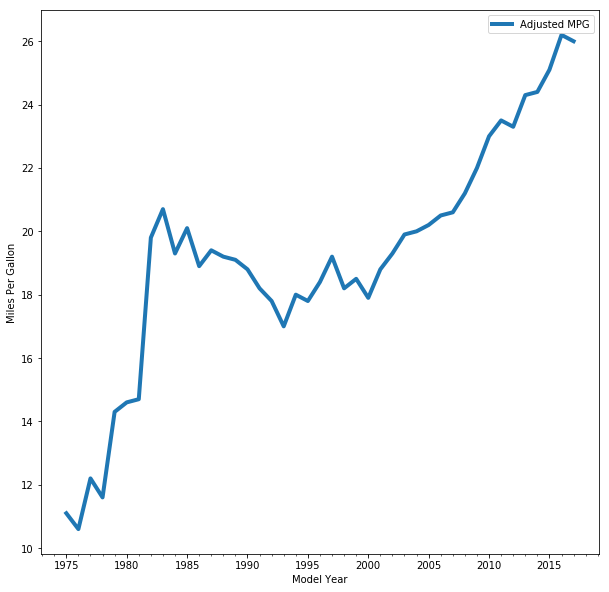

In [35]:
fig = plt.figure(figsize=(10,10))
ax = fig.gca()

ecodf[
    ecodf['Vehicle Type']=='Car SUV'
]['Adjusted MPG'].plot(ax=ax, linewidth=4)

ax.legend()
plt.ylabel('Miles Per Gallon')

We can also change the fontsize and the general look.

Text(0.5, 0, 'Year')

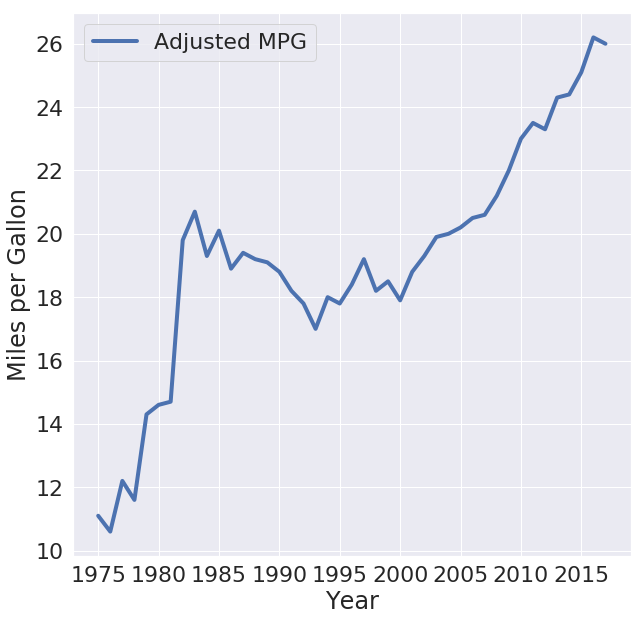

In [36]:
sns.set(font_scale=2)

fig = plt.figure(figsize=(10,10))
ax = fig.gca()

ecodf[
    ecodf['Vehicle Type']=='Car SUV'
]['Adjusted MPG'].plot(ax=ax, linewidth=4)

ax.legend()
plt.ylabel('Miles per Gallon')
plt.xlabel('Year')

The data has a lot of small variation that can make it
harder to see the overall trend.  Let's plot smoothed
data from a rolling average 
by combining the Pandas series functions `.rolling()` and `.mean()`.

Text(0.5, 0, 'Year')

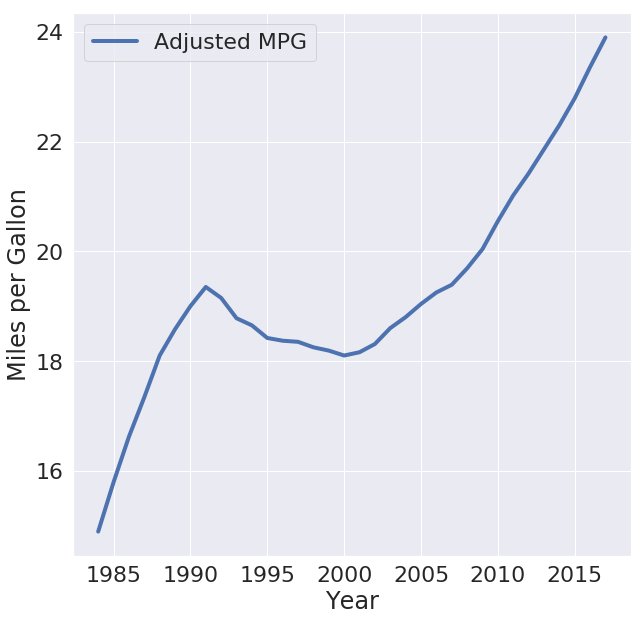

In [37]:
sns.set(font_scale=2)

fig = plt.figure(figsize=(10,10))
ax = fig.gca()

ecodf[
    ecodf['Vehicle Type']=='Car SUV'
]['Adjusted MPG'].rolling(10).mean().plot(ax=ax, linewidth=4)

ax.legend()
plt.ylabel('Miles per Gallon')
plt.xlabel('Year')

## Your turn, the fuel prices dataset

The goal of this portion of the notebook is to construct a correlation between **fuel prices** and **fuel efficiency**.  We've already imported and formatted the fuel efficiency dataset, but you'll be starting from the original .csv for the fuel prices dataset.

To do this consider the following challenge questions:

1. How do you format the fuel price data with a `datetime` index?  It may be helpful to distinguish between monthly values and yearly averages (the yearly averages end in "13" for this dataset).

2. How should you handle missing data in the `Value` column?

3. Do you see a trend in regular unleaded gas prices? (`MSN` column is `RUUCUUS` for regular unleaded gas)

4. Find a correlation between the **fuel price** and **fuel efficiency**.  To do this you may want to combine the relevant values from the different dataframes using `pd.merge_asof()` and then use the function `.corr()` on the combined dataframe.

5. Try to plot the **fuel price** and **fuel efficiency** on the same plot, but with different y-axis scales -- do you observe a correlation?

6. Plot **fuel price** and **fuel efficiency** using a rolling average, for example `rolling(5).mean()` on a Pandas series to display a 5 year rolling average.  See above for an example of rolling average.  Plot the rolling averages like you plotted the values in the previous question.

5. Use seaborn's `jointplot()` to plot MPG vs Price to deduce a correlation.

### Getting started

First import the data

In [38]:
pricedf = pd.read_csv('MER_T09_04.csv')

Next, do two things:

1. Make a column called `Data Type` and mark it as `AVG` if the year string contains a `13`.
2. For each row that's an `AVG`, format the year string in one way.

In [43]:
def f(x):
    x = str(x)
    if x[-2:] == '13':
        return 'AVG'
    else:
        return ''
pricedf['Data Type'] = pricedf['YYYYMM'].apply(f)

def f(x):
    y = str(x['YYYYMM'])
    if x['Data Type'] == 'AVG':
        return pd.to_datetime(y[:4], format='%Y')
    else:
        return pd.to_datetime(y, format='%Y%m')

pricedf['Date'] = pricedf.apply(f, axis=1)

Now check to see what all of the `AVG` `Value` numbers look like.

In [45]:
pricedf[
    pricedf['Data Type'] == 'AVG'
]['Value']

0                0.268
1                0.268
2                0.272
3                0.274
4                0.287
5                 0.29
6                0.291
7                0.299
8                 0.31
9                0.304
10               0.305
11               0.311
12               0.308
13               0.306
14               0.304
15               0.304
16               0.312
17               0.321
18               0.332
19               0.337
20               0.348
21               0.357
22               0.364
23               0.361
36               0.388
49               0.532
62               0.567
75                0.59
88               0.622
101              0.627
             ...      
4585    Not Applicable
4598    Not Applicable
4611     Not Available
4624     Not Available
4637     Not Available
4650     Not Available
4663     Not Available
4676             1.109
4689             1.235
4702             1.198
4715             1.044
4728             1.121
4741       

For the next step you'll want to 

1. try to convert a number to a float
2. if the convertion doesn't work, then use not-a-number (np.nan)

In [49]:
try:
    y = float('1.23')
except:
    print('this should not print')
print(f'y={y}')

try:
    y = float('trace')
except:
    y = np.nan
    print('converted to nan')
    
print(f'y={y}')

y=1.23
converted to nan
y=nan


In [ ]:
#clear
def f(x):
    try:
        y = float(x)
    except:
        y = np.nan
    return y
pricedf['Value'] = pricedf['Value'].apply(f)

In [ ]:
#clear
pricedf[
    (pricedf['Data Type'] == 'AVG')
    &
    (pricedf['MSN'] == 'RLUCUUS')
][['Date','Value']]

In [ ]:
#clear
fig = plt.figure(figsize=(8,8))
ax = fig.gca()

sns.set(font_scale=1)

pricedf[
    (pricedf['Data Type'] == 'AVG')
    &
    (pricedf['MSN'] == 'RLUCUUS')
].plot(x='Date', y='Value', ax=ax, label='leaded')

pricedf[
    (pricedf['Data Type'] == 'AVG')
    &
    (pricedf['MSN'] == 'RUUCUUS')
].plot(x='Date', y='Value', ax=ax, label='unleaded')

In [ ]:
#clear
df1 = pricedf[
    (pricedf['Data Type'] == 'AVG')
    &
    (pricedf['MSN'] == 'RUUCUUS')
][['Date','Value']]

df1.set_index('Date', inplace=True)
df1

In [ ]:
#clear
fig = plt.figure(figsize=(8,8))
ax = fig.gca()

df1.plot(ax=ax)
df1.rolling(4).mean().plot(ax=ax)

In [ ]:
#clear
df0 = ecodf[
    (ecodf['Vehicle Type']=='All Car')
][['Adjusted MPG']]

df0

In [ ]:
#clear
dfboth = pd.merge_asof(df0, df1, left_index=True, right_index=True, direction='nearest')

In [ ]:
#clear
dfboth

In [ ]:
#clear
dfboth.plot()

In [ ]:
#clear
fig = plt.figure(figsize=(8,8))
ax = fig.gca()

ax1 = dfboth['Adjusted MPG'].rolling(5).mean().plot(label='MPG')
ax2 = dfboth['Value'].rolling(5).mean().plot(label='Gas Price', secondary_y=True)

ax1.legend(loc=2)
ax2.legend(loc=1)

In [ ]:
#clear
dfboth.corr()

In [ ]:
#clear
sns.jointplot(data=dfboth, x='Adjusted MPG', y='Value', kind='reg')